In [1]:
import numpy as np

def read_poscar(filename="relaxed-POSCAR"):
    with open(filename, "r") as f:
        lines = f.readlines()

    scale = float(lines[1].strip())
    a_vec = [float(x) for x in lines[2].split()]
    b_vec = [float(x) for x in lines[3].split()]
    c_vec = [float(x) for x in lines[4].split()]
    species_line = lines[5].strip()
    counts_line  = lines[6].strip()
    coord_type   = lines[7].strip()
    atom_coords  = [lines[i].strip() for i in range(8, len(lines)) if lines[i].strip()]

    return scale, a_vec, b_vec, c_vec, species_line, counts_line, coord_type, atom_coords

strain_list = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16, 18]

scale, a_vec, b_vec, c_vec, species_line, counts_line, coord_type, atom_coords = read_poscar()

for i in strain_list:
    factor = 1 + i / 100

    # Only scale the in-plane (x, y) components; leave z untouched
    def strain_vec(v):
        return [v[0] * factor, v[1] * factor , v[2]]

    a_s = strain_vec(a_vec)
    b_s = strain_vec(b_vec)
    c_s = strain_vec(c_vec)

    filename = f"POSCAR-{i}"
    content = (
        f"Buckled BiAs strained {i}%\n"
        f"   {scale:.14f}\n"
        f"\t{a_s[0]:.15f}\t{a_s[1]:.15f}\t{a_s[2]:.15f}\n"
        f"\t{b_s[0]:.15f}\t{b_s[1]:.15f}\t{b_s[2]:.15f}\n"
        f"\t{c_s[0]:.15f}\t{c_s[1]:.15f}\t{c_s[2]:.15f}\n"
        f"   {species_line}\n"
        f"    {counts_line}\n"
        f"{coord_type}\n"
    )
    for coord in atom_coords:
        content += f"\t{coord}\n"

    with open(filename, "w") as f:
        f.write(content)

    print(f"Written: {filename}")

Written: POSCAR-2
Written: POSCAR-4
Written: POSCAR-6
Written: POSCAR-8
Written: POSCAR-10
Written: POSCAR-11
Written: POSCAR-12
Written: POSCAR-13
Written: POSCAR-14
Written: POSCAR-16
Written: POSCAR-18


[0.0, 0.443, 1.328, 2.214, 2.981]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.434, 1.303, 2.171, 2.923]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.426, 1.278, 2.13, 2.868]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.418, 1.254, 2.091, 2.815]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.411, 1.232, 2.053, 2.764]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.407, 1.221, 2.034, 2.739]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.403, 1.21, 2.016, 2.715]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.4, 1.199, 1.998, 2.691]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.396, 1.188, 1.981, 2.667]
Number of bands below Fermi level in DFT data: 60
[0.0, 0.389, 1.168, 1.947, 2.621]
Number of bands below Fermi level in DFT data: 60


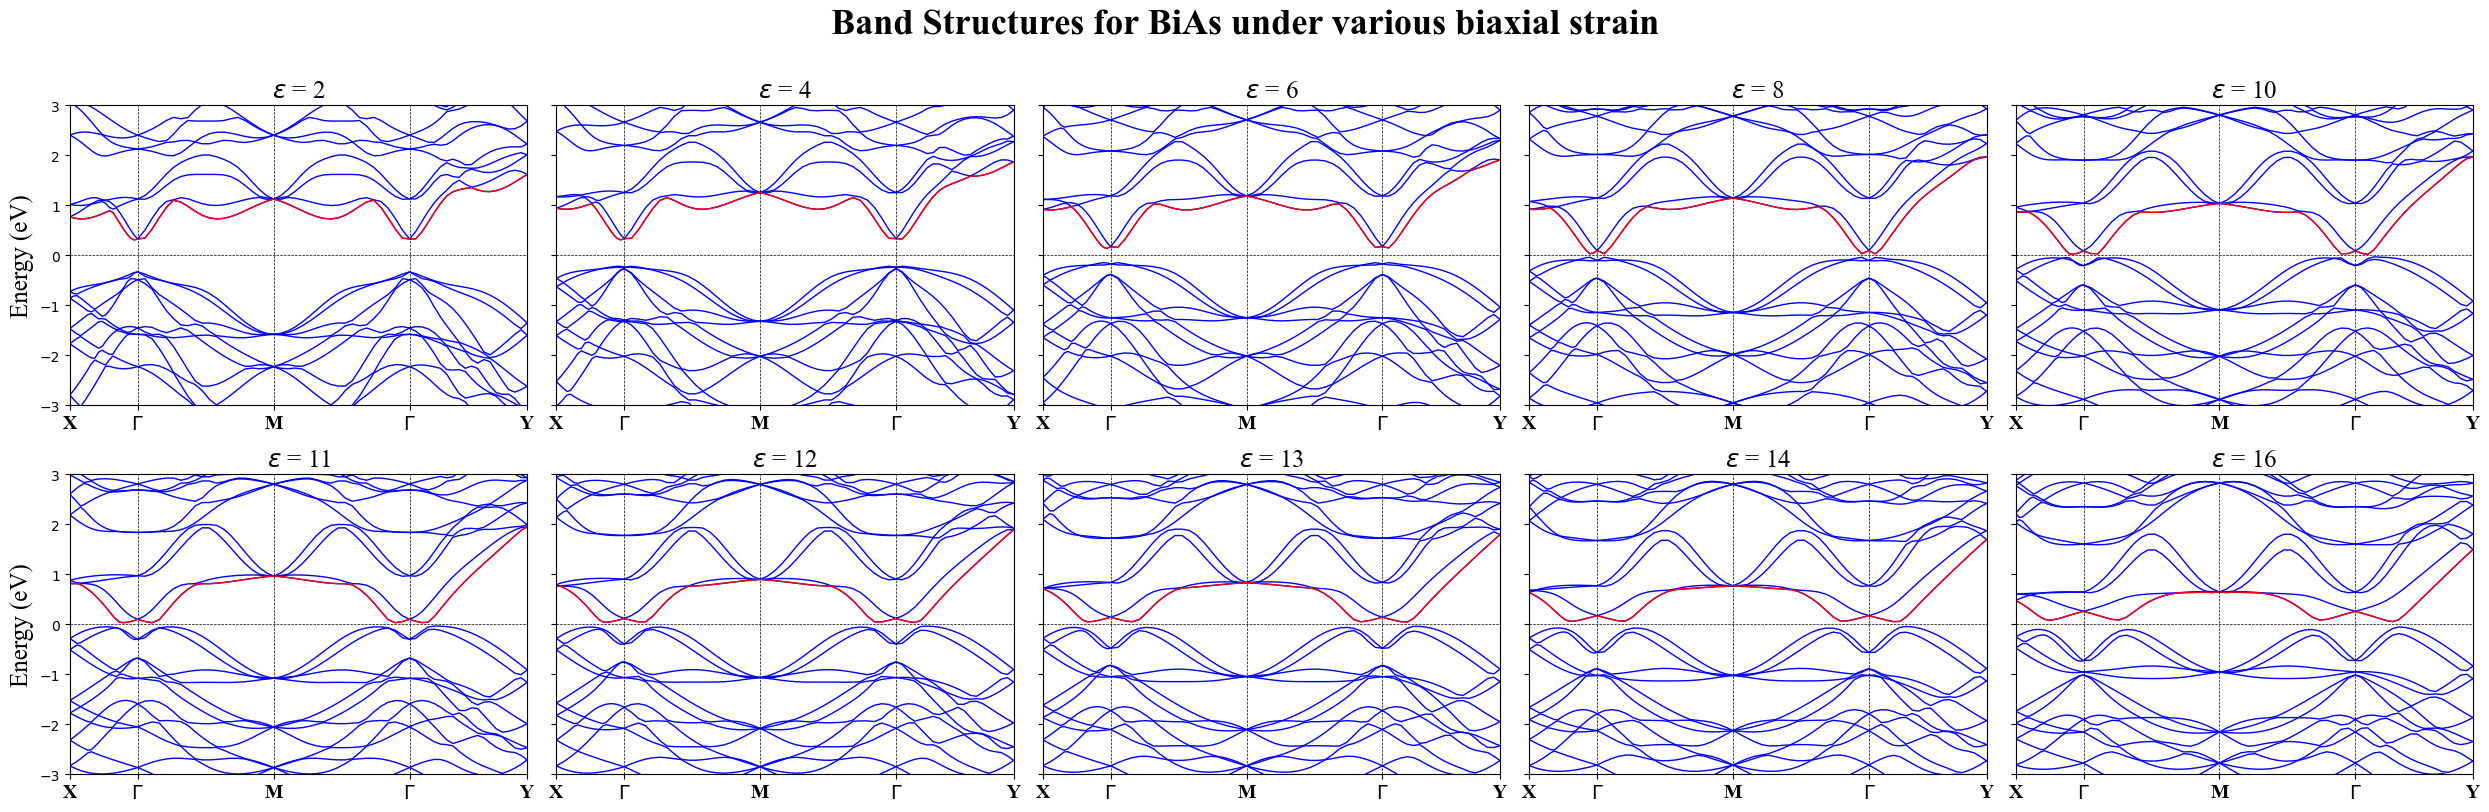

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Config ---
file_indices = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]
high_symmetry_points = [0, 0.780, 1.456, 1.846, 2.626]
high_sym_labels = ['X', r'$\Gamma$', 'M',  r'$\Gamma$', 'Y']

# --- Load all datasets ---
datasets = {i: np.loadtxt(f"{i}-REFORMATTED_BAND.dat") for i in file_indices}

# --- Layout: 4 cols, enough rows to fit all ---
n_plots = len(file_indices)
n_cols = 5
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows),
                          sharey=True)
axes = axes.flatten()

def read_klabels(filename):
    """
    Parse a KLABELS file and return the list of k-path positions.
    Skips the header line and any empty lines.
    """
    points = []
    with open(filename, 'r') as f:
        lines = f.readlines()
    # Skip header (first line), read lines with two columns
    for line in lines[1:]:
        stripped = line.strip()
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) == 2:
            try:
                points.append(float(parts[1]))
            except ValueError:
                continue
    return points

for ax, (idx, data) in zip(axes, datasets.items()):
    k = data[:, 0]
    bands = data[:, 1:]
    high_sym_points = read_klabels(f"labels/{idx}-KLABELS")
    print(high_sym_points)
    for i in range(bands.shape[1]):
        ax.plot(k, bands[:, i], color='blue', linewidth=1, label='DFT' if i == 0 else "")
    ax.plot(k, bands[:, 60], color='red', linewidth=1, label='DFT' if i == 0 else "")
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax.set_xlim(k.min(), k.max())

    for i in range(len(high_sym_points)):
        ax.axvline(high_sym_points[i],lw=0.5,ls="--",color='black')

    ax.set_ylim(-3, 3)
    ax.set_xticks(high_sym_points)
    ax.set_xticklabels(high_sym_labels, fontsize=14, fontname="Times New Roman",fontweight="bold")
    ax.set_title(rf'$\epsilon$ = {idx}',fontsize=18, fontname="Times New Roman")
    num_bands_below_fermi = np.sum(bands[0, :] < 0) 

    print(f"Number of bands below Fermi level in DFT data: {num_bands_below_fermi}")
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('Energy (eV)', fontsize=18, fontname="Times New Roman")

# Hide any unused subplots
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle('Band Structures for BiAs under various biaxial strain', fontsize=26, fontname="Times New Roman",fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

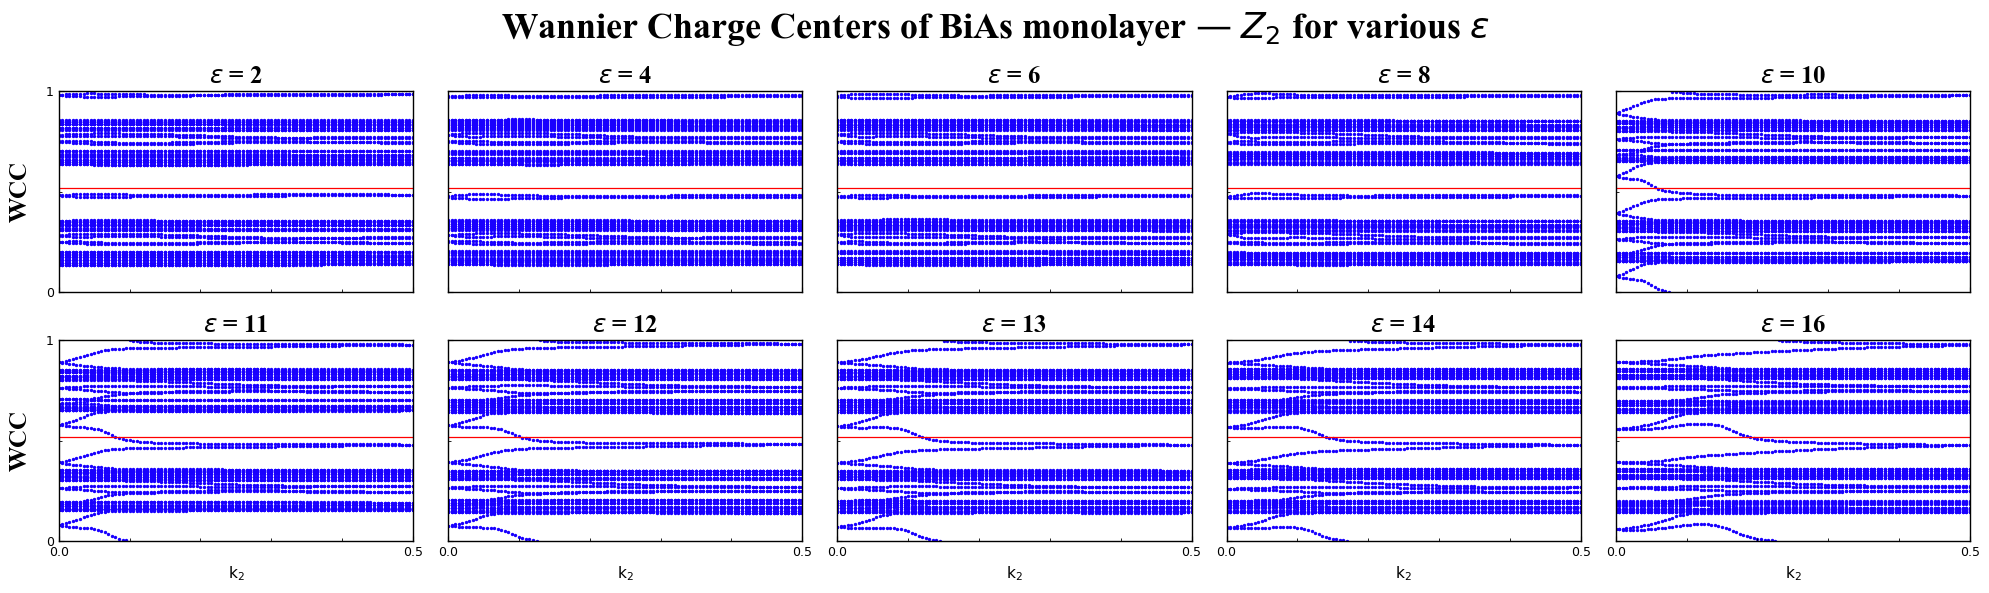

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Config ---
LCOLOR = "#1900FF"
file_indices = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]

n_plots = len(file_indices)
n_cols = 5
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, idx in zip(axes, file_indices):
    try:
        data = np.loadtxt(f"{idx}-wanniercenter3D_Z2_6.dat")
        ax.scatter(data[:, 0] / 2, data[:, 1],
                   s=2, color=LCOLOR, marker='o', linewidths=1)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'e{idx} not found',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)

    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 1)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.tick_params(axis='x', which='both', direction='in', labelsize=9)
    ax.axhline(0.52,lw = 0.9, color='red', ls = '-')
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%1.0f'))
    ax.tick_params(axis='y', which='both', direction='in', labelsize=9)

    ax.set_title(rf'$\epsilon$ = {idx}', fontname="Times New Roman",fontweight="bold",fontsize=18)

    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('WCC', rotation=90, fontname="Times New Roman",fontweight="bold", fontsize=18, labelpad=10)
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel(r'k$_2$', fontsize=11)

    for spine in ax.spines.values():
        spine.set_linewidth(1)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle(r'Wannier Charge Centers of BiAs monolayer — $Z_2$ for various $\epsilon$', fontname="Times New Roman",fontweight="bold",fontsize=26)
plt.tight_layout()
plt.savefig("bias_wannier_centers_comparison_biaxial.png", dpi=300)
plt.show()

Global DOS range: [2.4327296, 7.9890274]


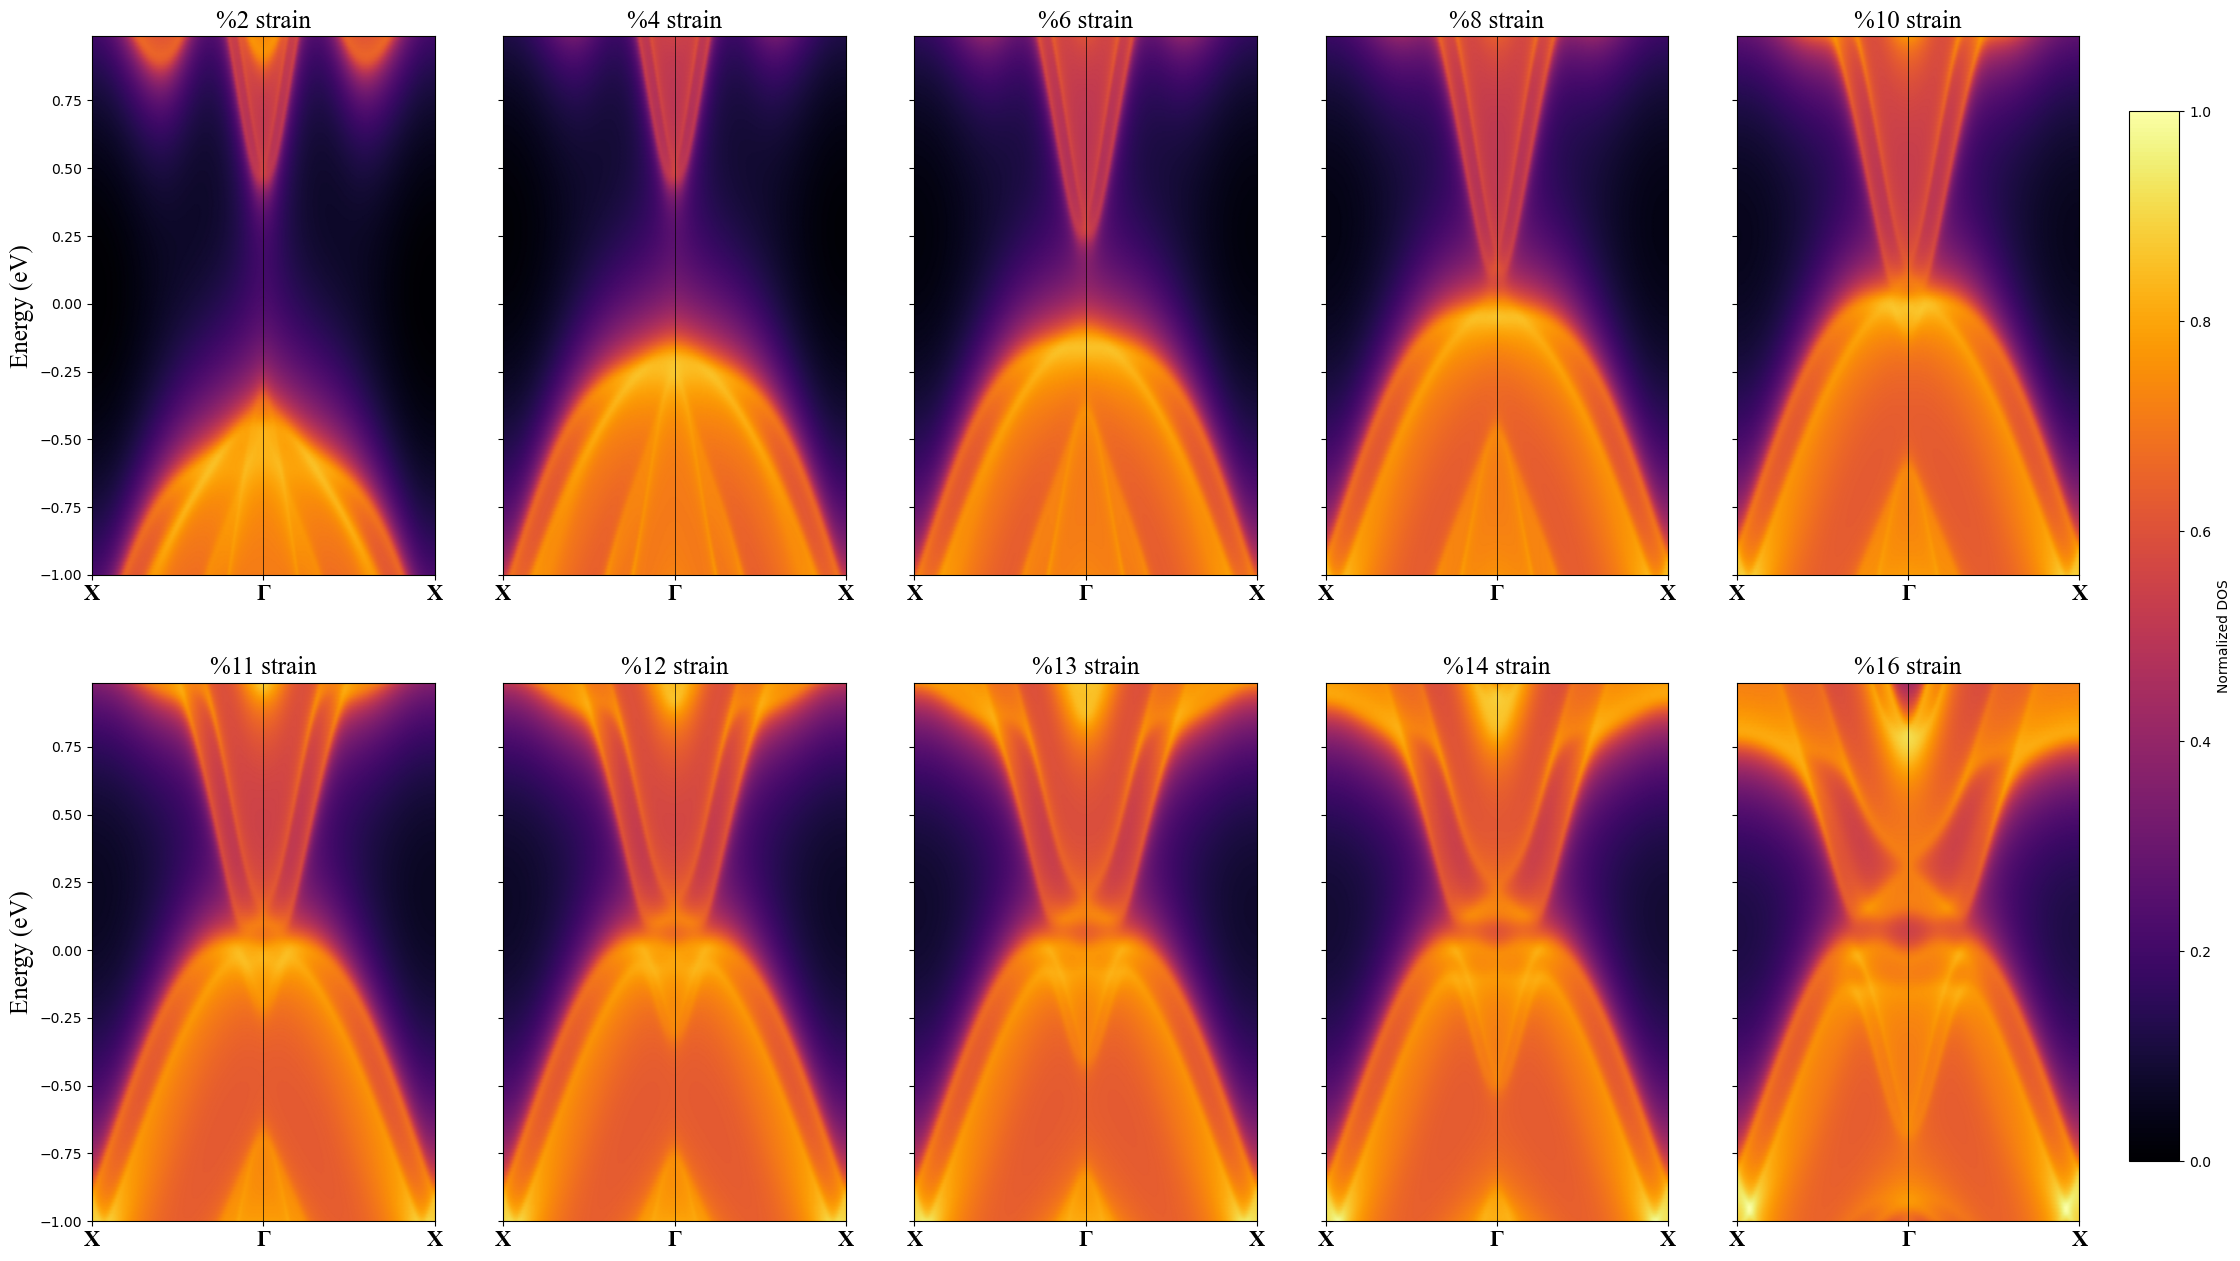

Plot displayed!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import griddata

# Loading all data
data_2 = np.loadtxt("2-dos.dat_bulk")
data_4 = np.loadtxt("4-dos.dat_bulk")
data_6 = np.loadtxt("6-dos.dat_bulk")
data_8 = np.loadtxt("8-dos.dat_bulk")
data_10 = np.loadtxt("10-dos.dat_bulk")
data_11 = np.loadtxt("11-dos.dat_bulk")
data_12 = np.loadtxt("12-dos.dat_bulk")
data_13 = np.loadtxt("13-dos.dat_bulk")
data_14 = np.loadtxt("14-dos.dat_bulk")
data_16 = np.loadtxt("16-dos.dat_bulk")

# Collect all datasets
datasets = [data_2, data_4, data_6, data_8, data_10, data_11, data_12, data_13, data_14, data_16]
labels = ['2', '4', '6', '8', '10', '11', '12', '13', '14', '16']

# Find global min and max of DOS values across all datasets
global_min = min(data[:, 2].min() for data in datasets)
global_max = max(data[:, 2].max() for data in datasets)

print(f"Global DOS range: [{global_min}, {global_max}]")

# Normalize all datasets to [0, 1] range
normalized_datasets = []
for data in datasets:
    data_normalized = data.copy()
    # Min-max normalization
    data_normalized[:, 2] = (data[:, 2] - global_min) / (global_max - global_min)
    normalized_datasets.append(data_normalized)

from matplotlib.colors import LinearSegmentedColormap

# Define custom black-white-yellow colormap
colors = ['#000000', '#FFFFFF', "#FFAE00"]
n_bins = 256  # Discretizes the interpolation into bins
cmap_custom = LinearSegmentedColormap.from_list('black_white_yellow', colors, N=n_bins)

# Function to plot a single dataset
def plot_dos(data, title_suffix, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    x = data[:, 0]
    y = data[:, 1]
    z = data[:, 2]  # Already normalized, no exponential needed
    
    # Create interpolated grid for smooth plotting
    xi = np.linspace(x.min(), x.max(), 400)
    yi = np.linspace(y.min(), y.max(), 400)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), z, (Xi, Yi), method='cubic')
    
    # Plot the data
    im = ax.pcolormesh(Xi, Yi, Zi, cmap="inferno", shading='gouraud', 
                       vmin=0, vmax=1)  # Fixed scale [0, 1]
    
    # Set axis limits
    ax.set_xlim(min(x), max(x))
    
    # Set x-axis ticks and labels
    ax.set_xticks([min(x), (min(x)+max(x))/2, max(x)])
    ax.set_xticklabels(['X', 'Γ', 'X'],fontname="Times New Roman", fontweight="bold",fontsize=16)
    
    
    # Add vertical line at Gamma point
    ax.axvline(x=(min(x)+max(x))/2, color='black', linewidth=0.5)

    ax.set_title(f"%{title_suffix} strain",fontname="Times New Roman", fontsize=18)

    return im

# Create a comparison plot with all datasets
fig, axes = plt.subplots(2, 5, figsize=(25, 15),sharey=True)
axes = axes.flatten()

for i, (data, label) in enumerate(zip(normalized_datasets, labels)):
    im = plot_dos(data, label, axes[i])
    if i == 0 or i == 5:
        axes[i].set_ylabel('Energy (eV)', fontname="Times New Roman", fontsize=18)
# Adjust subplot spacing to make room for colorbar on the right
fig.subplots_adjust(right=0.92, top=0.90)  # Added top spacing for title


# Add a shared colorbar on the far right
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='Normalized DOS')
plt.savefig("surface_states_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot displayed!")

Global log(edge DOS) range: [0.350, 0.858]  (l and r shared)


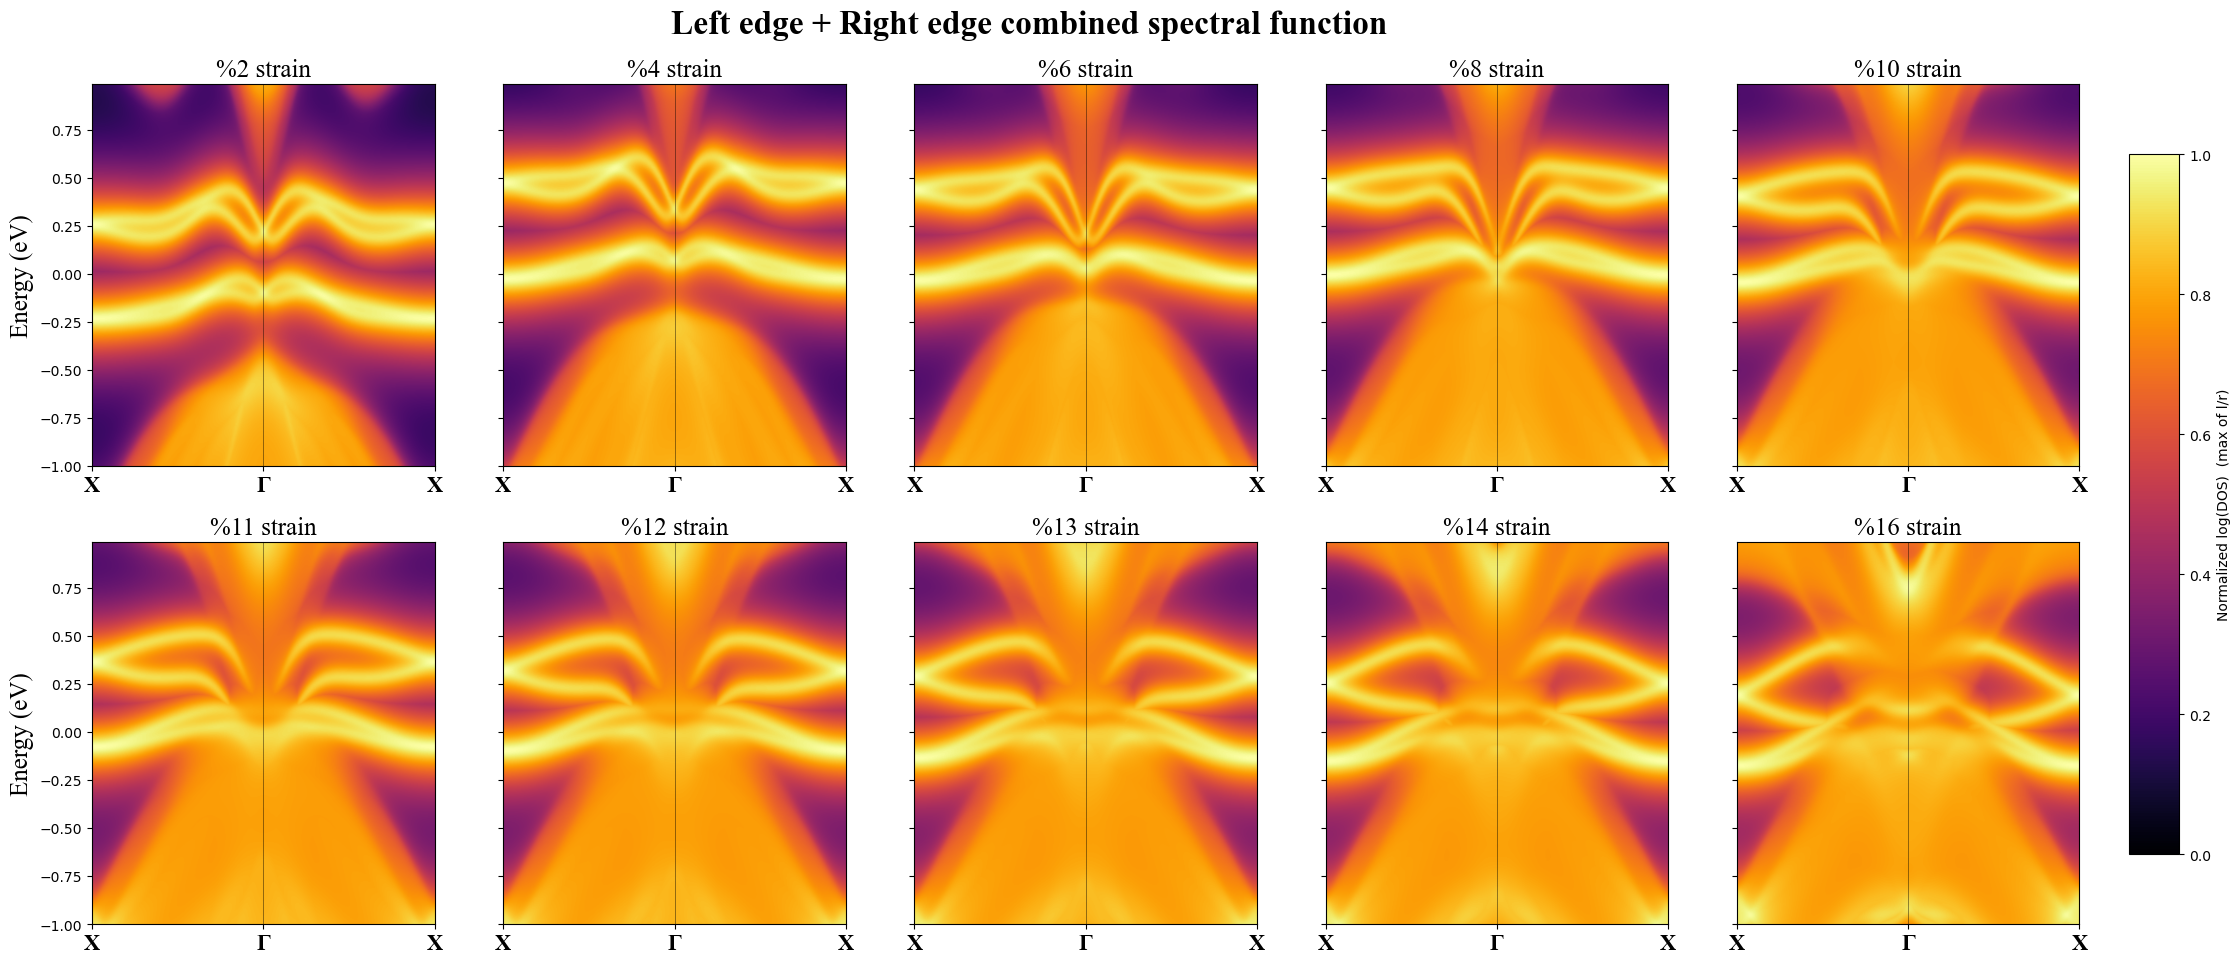

Combined edge plot saved as edge_states_combined.png


In [1]:
"""
Combined LEFT + RIGHT edge spectral function plot (bulk excluded).

Reads, for each strain value, two WannierTools output files:
    {strain}-dos.dat_l
    {strain}-dos.dat_r

Both are normalized together on a SHARED global log-scale (so their
intensities are directly comparable), combined via element-wise max,
and plotted with a single colormap (inferno by default).

Usage:
    Edit STRAINS below, make sure the two files exist per strain in the
    working directory, then run the script.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# ------------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------------

STRAINS = ['2', '4', '6', '8', '10', '11', '12', '13', '14', '16']
EPS = 1e-6
GRID_N = 400
CMAP = "inferno"    # change to "coolwarm", "viridis", etc. if preferred

# ------------------------------------------------------------------
# 2. Load all files
# ------------------------------------------------------------------

def load_strain_data(strain):
    try:
        left = np.loadtxt(f"{strain}-dos.dat_l")
        right = np.loadtxt(f"{strain}-dos.dat_r")
    except OSError as e:
        print(f"[warning] skipping strain {strain}%: missing file ({e})")
        return None
    return {"l": left, "r": right}


data_by_strain = {}
for s in STRAINS:
    d = load_strain_data(s)
    if d is not None:
        data_by_strain[s] = d

if not data_by_strain:
    raise RuntimeError("No data loaded - check file names/paths.")

valid_strains = list(data_by_strain.keys())

# ------------------------------------------------------------------
# 3. Global log-normalization: l and r share the SAME range
# ------------------------------------------------------------------

def log_col(z):
    return np.log10(z + EPS)


edge_logs = []
for d in data_by_strain.values():
    edge_logs.append(log_col(d["l"][:, 2]))
    edge_logs.append(log_col(d["r"][:, 2]))

edge_min = min(a.min() for a in edge_logs)
edge_max = max(a.max() for a in edge_logs)
print(f"Global log(edge DOS) range: [{edge_min:.3f}, {edge_max:.3f}]  (l and r shared)")


def normalize(z_raw, lo, hi):
    z = log_col(z_raw)
    return np.clip((z - lo) / (hi - lo), 0.0, 1.0)


# ------------------------------------------------------------------
# 4. Interpolate l and r onto a common grid, combine via element-wise max
# ------------------------------------------------------------------

def interp_to_grid(data, value_col, xi, yi):
    x, y = data[:, 0], data[:, 1]
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), value_col, (Xi, Yi), method="cubic")
    return np.nan_to_num(Zi, nan=0.0)


def build_combined_edges(d):
    x = d["l"][:, 0]
    y = d["l"][:, 1]
    xi = np.linspace(x.min(), x.max(), GRID_N)
    yi = np.linspace(y.min(), y.max(), GRID_N)

    left_n = normalize(d["l"][:, 2], edge_min, edge_max)
    right_n = normalize(d["r"][:, 2], edge_min, edge_max)

    Zi_left = interp_to_grid(d["l"], left_n, xi, yi)
    Zi_right = interp_to_grid(d["r"], right_n, xi, yi)

    # Whichever edge is stronger at a given (k,E) point sets the intensity.
    combined = np.maximum(Zi_left, Zi_right)
    combined = np.clip(combined, 0.0, 1.0)

    extent = [x.min(), x.max(), y.min(), y.max()]
    return combined, extent


# ------------------------------------------------------------------
# 5. Plot all strains in a grid
# ------------------------------------------------------------------

n = len(valid_strains)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), sharey=True)
axes = np.array(axes).flatten()

im = None
for i, s in enumerate(valid_strains):
    combined, extent = build_combined_edges(data_by_strain[s])
    ax = axes[i]
    im = ax.imshow(combined, origin="lower", extent=extent, aspect="auto",
                    cmap=CMAP, vmin=0, vmax=1)

    x = data_by_strain[s]["l"][:, 0]
    ax.set_xlim(x.min(), x.max())
    ax.set_xticks([x.min(), (x.min() + x.max()) / 2, x.max()])
    ax.set_xticklabels(["X", "Γ", "X"], fontname="Times New Roman",
                        fontweight="bold", fontsize=16)
    ax.axvline(x=(x.min() + x.max()) / 2, color="black", linewidth=0.5, alpha=0.6)
    ax.set_title(f"%{s} strain", fontname="Times New Roman", fontsize=18)

    if i % ncols == 0:
        ax.set_ylabel("Energy (eV)", fontname="Times New Roman", fontsize=18)

for j in range(n, len(axes)):
    axes[j].axis("off")

fig.suptitle("Left edge + Right edge combined spectral function",
             fontname="Times New Roman", fontweight="bold", fontsize=24, y=0.995)

fig.subplots_adjust(right=0.92, top=0.92, bottom=0.08)

cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Normalized log(DOS)  (max of l/r)")

plt.savefig("edge_states_combined.png", dpi=300, bbox_inches="tight")
plt.show()
print("Combined edge plot saved as edge_states_combined.png")

Global log(bulk DOS) range: [0.386, 0.902]
Global log(edge DOS) range: [0.350, 0.858]  (l and r shared)


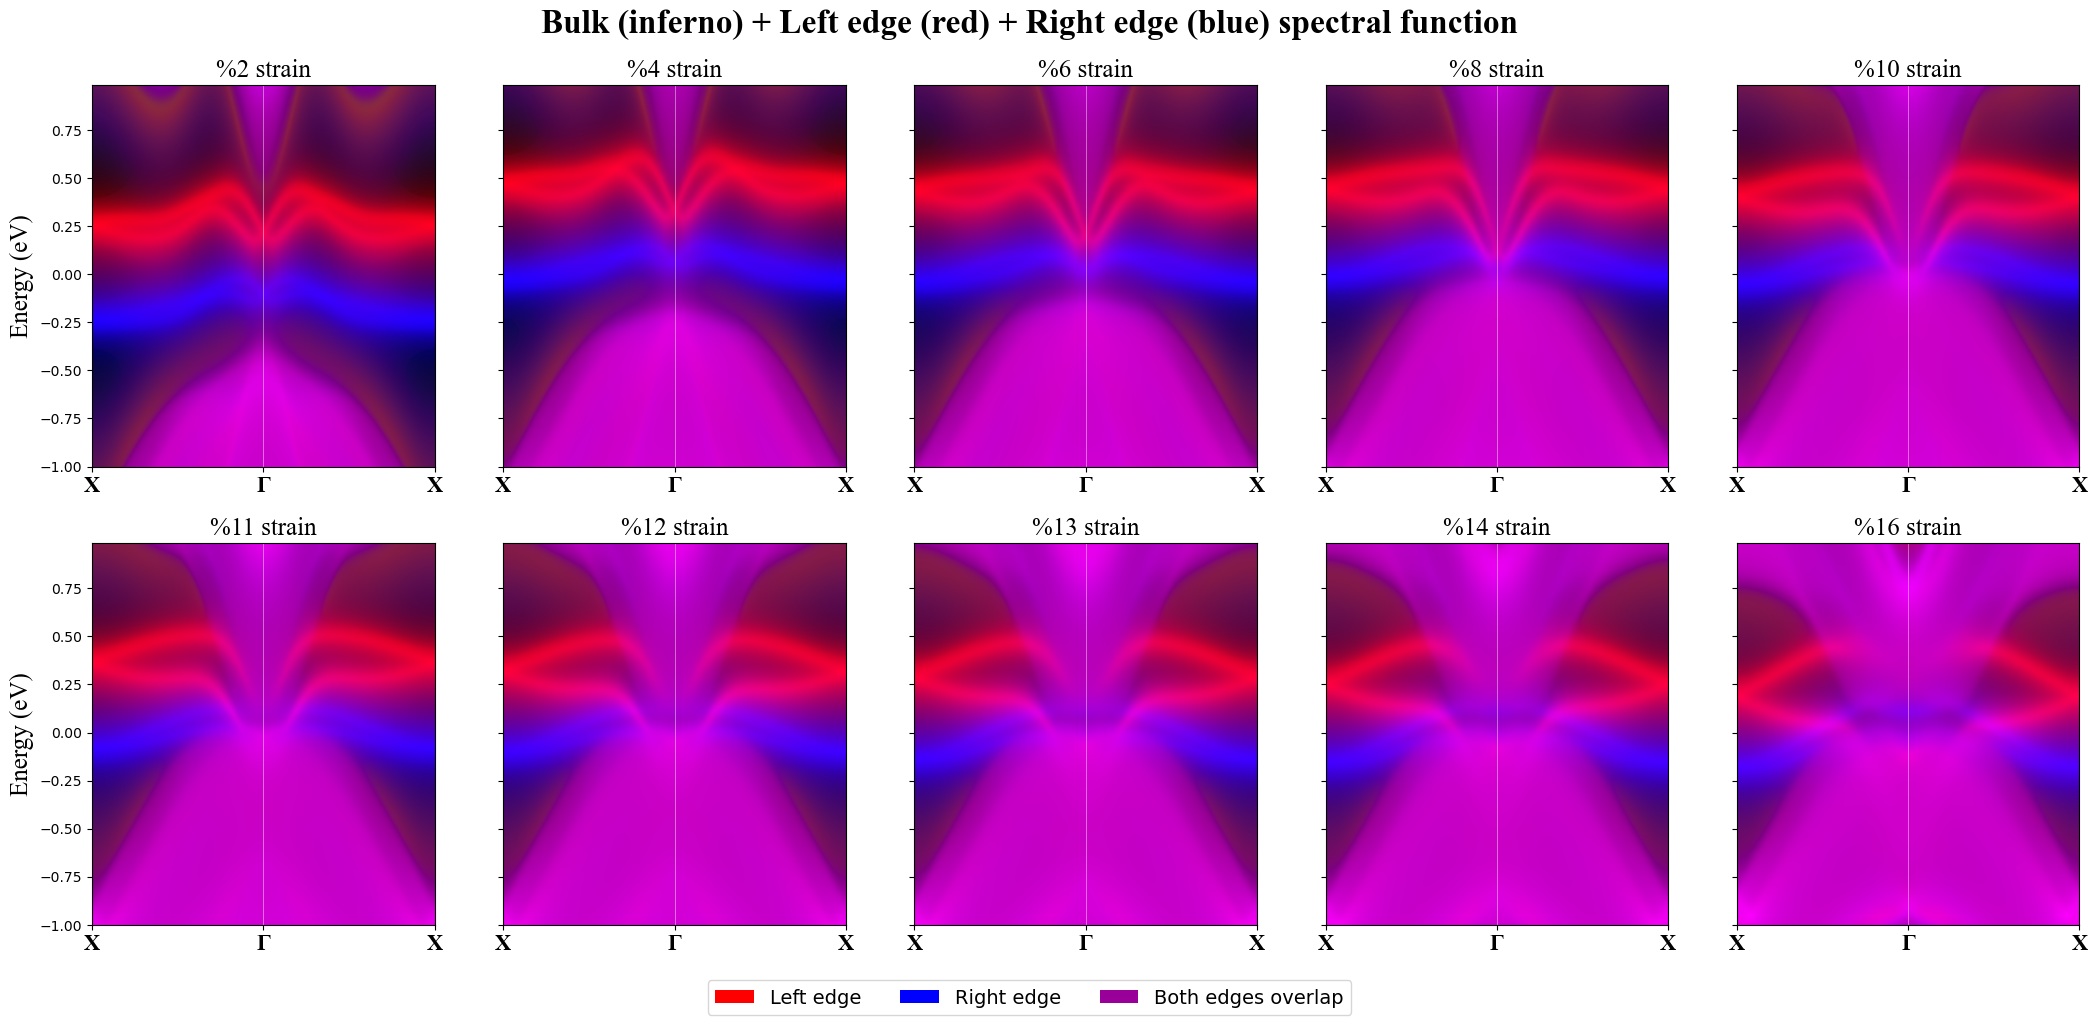

Combined plot saved as surface_states_combined.png


In [2]:
"""
Combined bulk + left-edge + right-edge spectral function plot.

Reads, for each strain value, three WannierTools output files:
    {strain}-dos.dat_bulk
    {strain}-dos.dat_l
    {strain}-dos.dat_r

and produces a single composite image per strain where:
    - the bulk projected DOS is shown as a grayscale/inferno background
      (own global log-normalization across all strains)
    - the left-edge DOS is shown in RED
    - the right-edge DOS is shown in BLUE
      (l and r share a common global log-normalization across all strains,
       since we want their relative intensity to be directly comparable)

Where left and right edge intensity overlap, the colors add (-> magenta/purple),
which is a useful visual cue that both edges contribute at that (k, E) point
(e.g. due to finite-ribbon hybridization).

Usage:
    Just edit STRAINS below and make sure the three files exist per strain
    in the working directory, then run the script.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# ------------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------------

STRAINS = ['2', '4', '6', '8', '10', '11', '12', '13', '14', '16']
EPS = 1e-6          # log(0) guard
GRID_N = 400         # interpolation grid resolution
EDGE_THRESHOLD = 0.05  # below this normalized edge intensity, treat as "no edge weight"
                       # (keeps the bulk background clean instead of a faint color wash)

# ------------------------------------------------------------------
# 2. Load all files
# ------------------------------------------------------------------

def load_strain_data(strain):
    """Load bulk/l/r files for a single strain value. Returns dict or None if missing."""
    try:
        bulk = np.loadtxt(f"{strain}-dos.dat_bulk")
        left = np.loadtxt(f"{strain}-dos.dat_l")
        right = np.loadtxt(f"{strain}-dos.dat_r")
    except OSError as e:
        print(f"[warning] skipping strain {strain}%: missing file ({e})")
        return None
    return {"bulk": bulk, "l": left, "r": right}


data_by_strain = {}
for s in STRAINS:
    d = load_strain_data(s)
    if d is not None:
        data_by_strain[s] = d

if not data_by_strain:
    raise RuntimeError("No data loaded - check file names/paths.")

valid_strains = list(data_by_strain.keys())

# ------------------------------------------------------------------
# 3. Compute global log-normalization ranges
#    - bulk gets its own global range
#    - l and r SHARE a global range (so their intensities are comparable)
# ------------------------------------------------------------------

def log_col(z):
    return np.log10(z + EPS)

bulk_logs = [log_col(d["bulk"][:, 2]) for d in data_by_strain.values()]
edge_logs = []
for d in data_by_strain.values():
    edge_logs.append(log_col(d["l"][:, 2]))
    edge_logs.append(log_col(d["r"][:, 2]))

bulk_min = min(a.min() for a in bulk_logs)
bulk_max = max(a.max() for a in bulk_logs)
edge_min = min(a.min() for a in edge_logs)
edge_max = max(a.max() for a in edge_logs)

print(f"Global log(bulk DOS) range: [{bulk_min:.3f}, {bulk_max:.3f}]")
print(f"Global log(edge DOS) range: [{edge_min:.3f}, {edge_max:.3f}]  (l and r shared)")


def normalize(z_raw, lo, hi):
    z = log_col(z_raw)
    return np.clip((z - lo) / (hi - lo), 0.0, 1.0)


# ------------------------------------------------------------------
# 4. Interpolate each dataset onto a common regular grid and
#    build an RGBA composite image
# ------------------------------------------------------------------

def interp_to_grid(data, value_col, xi, yi):
    x, y = data[:, 0], data[:, 1]
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), value_col, (Xi, Yi), method="cubic")
    return np.nan_to_num(Zi, nan=0.0)


def build_composite(d):
    x = d["bulk"][:, 0]
    y = d["bulk"][:, 1]
    xi = np.linspace(x.min(), x.max(), GRID_N)
    yi = np.linspace(y.min(), y.max(), GRID_N)

    bulk_n = normalize(d["bulk"][:, 2], bulk_min, bulk_max)
    left_n = normalize(d["l"][:, 2], edge_min, edge_max)
    right_n = normalize(d["r"][:, 2], edge_min, edge_max)

    Zi_bulk = interp_to_grid(d["bulk"], bulk_n, xi, yi)
    Zi_left = interp_to_grid(d["l"], left_n, xi, yi)
    Zi_right = interp_to_grid(d["r"], right_n, xi, yi)

    # Bulk background -> grayscale/inferno RGB (fully opaque)
    base_rgb = plt.colormaps["inferno"](Zi_bulk)[:, :, :3]

    # Edge overlay: red = left edge, blue = right edge, additive
    left_masked = np.where(Zi_left > EDGE_THRESHOLD, Zi_left, 0.0)
    right_masked = np.where(Zi_right > EDGE_THRESHOLD, Zi_right, 0.0)

    edge_rgb = np.zeros_like(base_rgb)
    edge_rgb[:, :, 0] = left_masked      # red channel <- left edge
    edge_rgb[:, :, 2] = right_masked     # blue channel <- right edge

    alpha_edge = np.clip(left_masked + right_masked, 0.0, 1.0)[:, :, None]

    composite = base_rgb * (1.0 - alpha_edge) + edge_rgb * alpha_edge
    composite = np.clip(composite, 0.0, 1.0)

    extent = [x.min(), x.max(), y.min(), y.max()]
    return composite, extent


# ------------------------------------------------------------------
# 5. Plot all strains in a grid
# ------------------------------------------------------------------

n = len(valid_strains)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), sharey=True)
axes = np.array(axes).flatten()

for i, s in enumerate(valid_strains):
    composite, extent = build_composite(data_by_strain[s])
    ax = axes[i]
    ax.imshow(composite, origin="lower", extent=extent, aspect="auto")

    x = data_by_strain[s]["bulk"][:, 0]
    ax.set_xlim(x.min(), x.max())
    ax.set_xticks([x.min(), (x.min() + x.max()) / 2, x.max()])
    ax.set_xticklabels(["X", "Γ", "X"], fontname="Times New Roman",
                        fontweight="bold", fontsize=16)
    ax.axvline(x=(x.min() + x.max()) / 2, color="white", linewidth=0.5, alpha=0.6)
    ax.set_title(f"%{s} strain", fontname="Times New Roman", fontsize=18)

    if i % ncols == 0:
        ax.set_ylabel("Energy (eV)", fontname="Times New Roman", fontsize=18)

# hide unused axes if any
for j in range(n, len(axes)):
    axes[j].axis("off")

fig.suptitle("Bulk (inferno) + Left edge (red) + Right edge (blue) spectral function",
             fontname="Times New Roman", fontweight="bold", fontsize=24, y=0.995)

# Manual legend for the two edge colors + bulk colorbar
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="red", edgecolor="none", label="Left edge"),
    Patch(facecolor="blue", edgecolor="none", label="Right edge"),
    Patch(facecolor=(0.6, 0, 0.6), edgecolor="none", label="Both edges overlap"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.02), fontsize=14)

fig.subplots_adjust(right=0.92, top=0.92, bottom=0.08)
plt.savefig("surface_states_combined.png", dpi=300, bbox_inches="tight")
plt.show()
print("Combined plot saved as surface_states_combined.png")

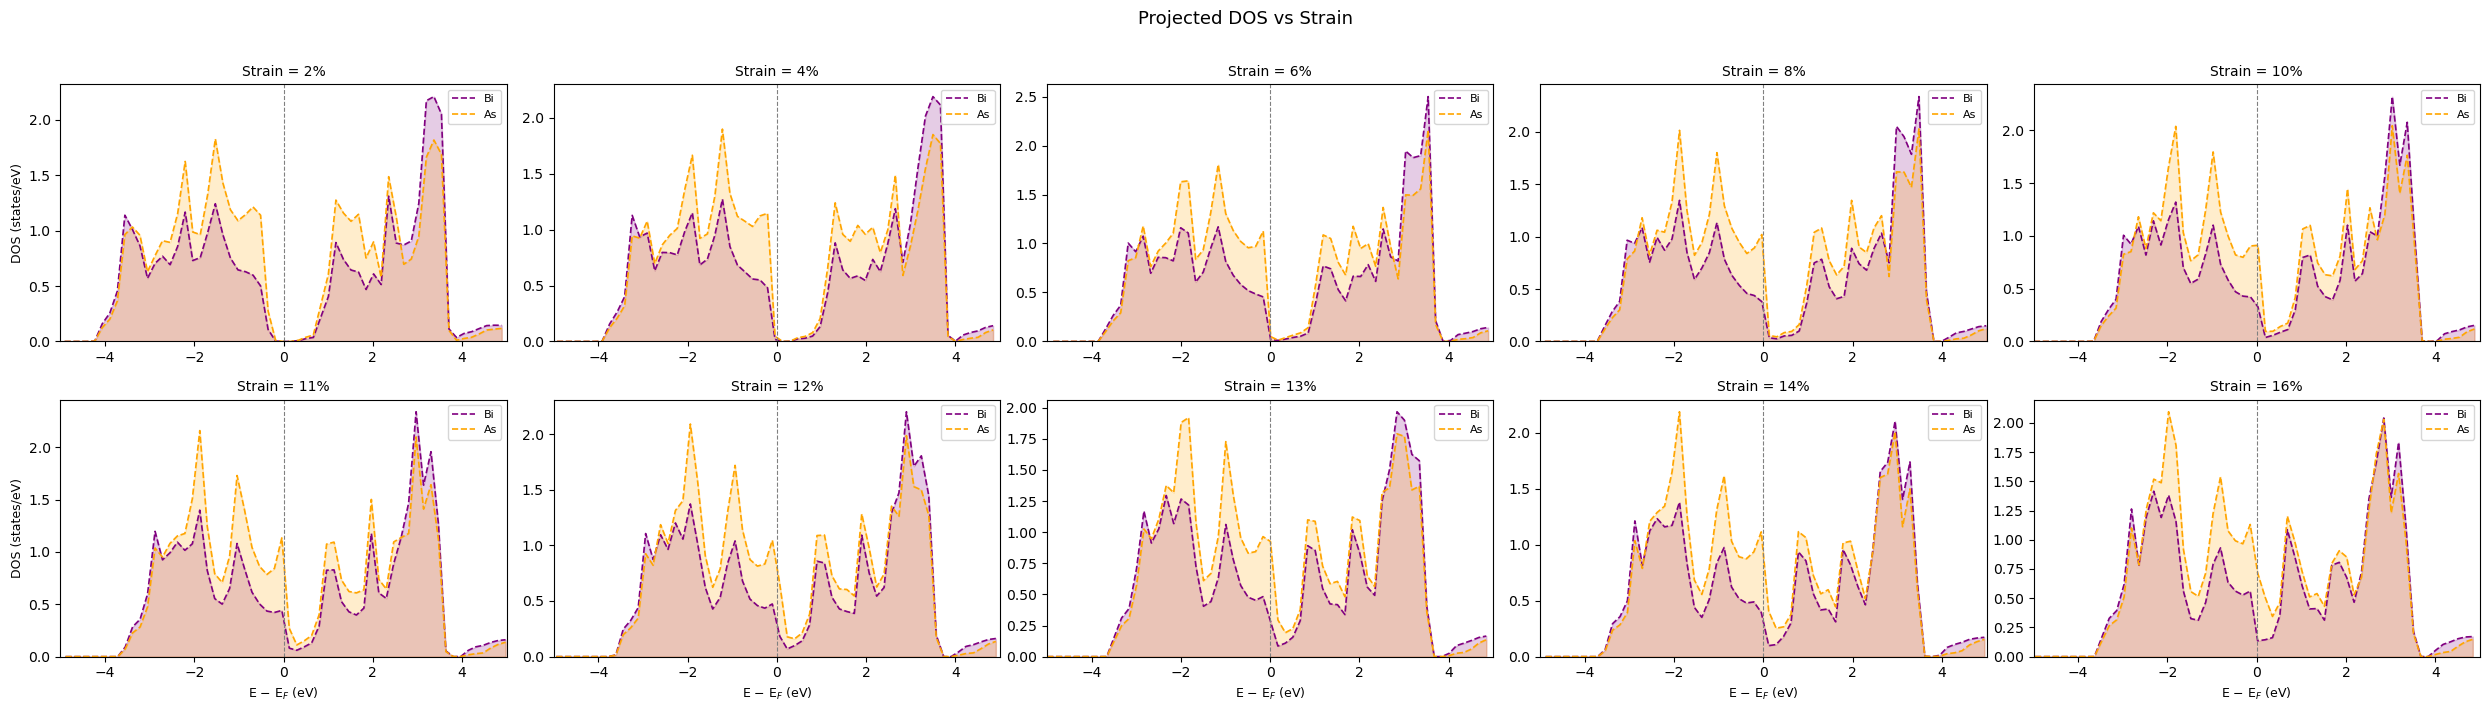

In [4]:
import numpy as np
import matplotlib.pyplot as plt

strains = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]

e_min, e_max = -5.0, 5.0

n = len(strains)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharey=False)
axes = axes.flatten()

for i, strain in enumerate(strains):
    ax = axes[i]

    # Load Bi and Sb PDOS
    bi_data = np.loadtxt(f'{strain}-PDOS_Bi_SOC.dat', unpack=True)
    sb_data = np.loadtxt(f'{strain}-PDOS_As_SOC.dat', unpack=True)

    energy = bi_data[0]
    tot_bi = bi_data[-1]   # last column = atom-summed total
    tot_sb = sb_data[-1]

    # Apply energy mask
    mask   = (energy >= e_min) & (energy <= e_max)
    energy = energy[mask]
    tot_bi = tot_bi[mask]
    tot_sb = tot_sb[mask]

    # Plot
    ax.plot(energy, tot_bi, label='Bi', color='purple', lw=1.2,ls = '--')
    ax.plot(energy, tot_sb, label='As', color='orange',  lw=1.2,ls = '--')
    ax.fill_between(energy, tot_bi, alpha=0.2, color='purple')
    ax.fill_between(energy, tot_sb, alpha=0.2, color='orange')

    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlim(e_min, e_max)
    ax.set_ylim(bottom=0)
    ax.set_title(f'Strain = {strain}%', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')

    # Only label outer axes
    if i % ncols == 0:
        ax.set_ylabel('DOS (states/eV)', fontsize=9)
    if i >= (nrows - 1) * ncols:
        ax.set_xlabel('E − E$_F$ (eV)', fontsize=9)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Projected DOS vs Strain', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('DOS_all_strains.png', dpi=150, bbox_inches='tight')
plt.show()